<a href="https://colab.research.google.com/github/giancarloliver/traffic-spliting_m-polka/blob/main/functional-tests/IdPerfil-0/funcional_test_packets_IdPerfil_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Switches  eth1  eth2  eth3    eth4  eth5  eth6
0      SW1  5019     0   0.0  5019.0   0.0   0.0
1      SW4  5019  5019   NaN     NaN   NaN   NaN
2      SW7  5019     0   0.0  5019.0   0.0   0.0


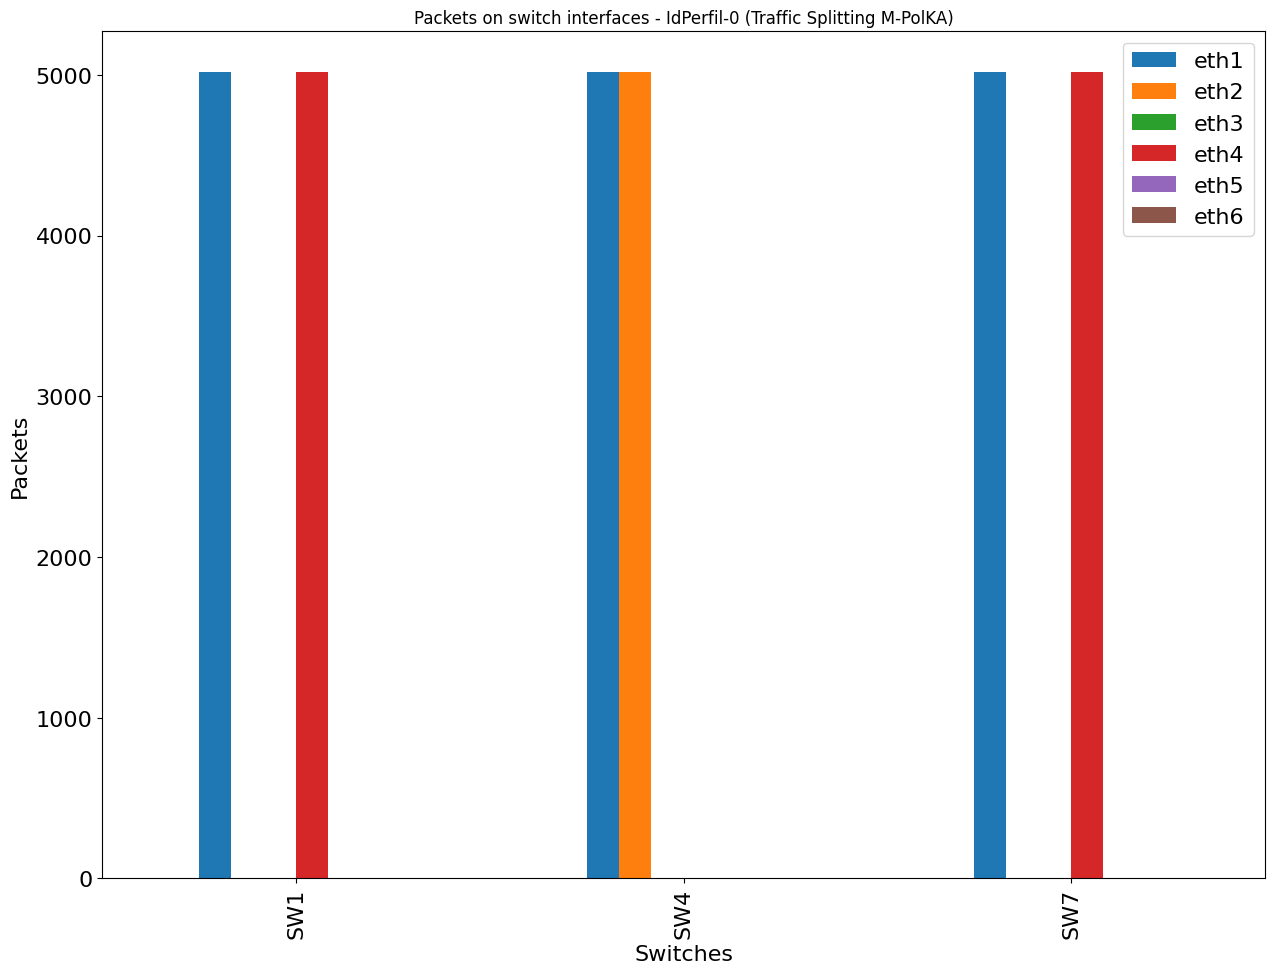

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas import DataFrame, read_csv
from google.colab import files

# File path of the data file
arq ='drive/MyDrive/Colab Notebooks/Teste_Traffic_M-Polka/IdPerfil-0/IpPerfil-packets-0.bwm'

# Column names for the data
colunas = ['unix_timestamp', 'interface', 'bytes_out_s', 'bytes_in_s', 'bytes_total_s', 'bytes_in', 'bytes_out', 'packets_out_s', 'packets_in_s', 'packets_total_s', 'packets_in', 'packets_out', 'errors_out_s', 'errors_in_s', 'errors_in', 'errors_out']

# Read the data from the CSV file
data = pd.read_csv(arq, delimiter=',', usecols=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15])
data.columns = colunas

# Filter the data for each interface of the switches
df_s1_1 = data.query('interface=="s1-eth1"')
df_s1_2 = data.query('interface=="s1-eth2"')
df_s1_3 = data.query('interface=="s1-eth3"')
df_s1_4 = data.query('interface=="s1-eth4"')
df_s1_5 = data.query('interface=="s1-eth5"')
df_s1_6 = data.query('interface=="s1-eth6"')

df_s4_1 = data.query('interface=="s4-eth1"')
df_s4_2 = data.query('interface=="s4-eth2"')

df_s7_1 = data.query('interface=="s7-eth1"')
df_s7_2 = data.query('interface=="s7-eth2"')
df_s7_3 = data.query('interface=="s7-eth3"')
df_s7_4 = data.query('interface=="s7-eth4"')
df_s7_5 = data.query('interface=="s7-eth5"')
df_s7_6 = data.query('interface=="s7-eth6"')

# Calculate the sum of packets in and out for each interface
df = pd.DataFrame([
                  ['SW1', sum(df_s1_1['packets_in']), sum(df_s1_2['packets_out']), sum(df_s1_3['packets_out']), sum(df_s1_4['packets_out']), sum(df_s1_5['packets_out']), sum(df_s1_6['packets_out'])],
                  #['SW2', sum(df_s1_2['packets_in']), sum(df_s1_2['packets_out'])],
                  ['SW4', sum(df_s4_1['packets_in']), sum(df_s4_2['packets_out'])],
                  ['SW7', sum(df_s7_1['packets_out']), sum(df_s7_2['packets_in']), sum(df_s7_3['packets_in']), sum(df_s7_4['packets_in']), sum(df_s7_5['packets_in']), sum(df_s7_6['packets_in']),]
                  ],
                  columns=['Switches', 'eth1', 'eth2','eth3' ,'eth4','eth5','eth6'])

print(df)

# Create the bar chart
ax = df.plot(x='Switches', ylabel='Packets', fontsize=16, figsize=(15, 11), kind='bar', title='Packets on switch interfaces - IdPerfil-0 (Traffic Splitting M-PolKA)')
ax.set_xlabel('Switches', fontsize=16)
ax.set_ylabel('Packets', fontsize=16)
ax.legend(fontsize=16)

# Display the plot
plt.show()